<a href="https://colab.research.google.com/github/mvanamali-27/DIP-rPPG/blob/main/notebooks/02_signal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q mediapipe==1.1.0

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
if os.path.isdir("DIP-rPPG"):
    !cd DIP-rPPG && git pull -q
else:
    !git clone -q https://github.com/mvanamali-27/DIP-rPPG.git

In [4]:
import sys; sys.path.append("DIP-rPPG/src")
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import data, roi
import signal_proc as sp

z = lambda x: (x - x.mean()) / x.std()      # rescale a signal so different ones fit one plot

In [5]:
subs = data.find_subjects()
videos = {s: v for s, v, g in subs}
gts = {s: g for s, v, g in subs}
print(f"Found {len(subs)} subjects")

sid = "subject_10"
vid, gt = videos[sid], gts[sid]
info = roi.video_info(vid)
print(sid, info)

n_read = 0
for frame in roi.iter_frames(vid):
    if n_read == 0:
        first = frame
    n_read += 1

ppg, hr, t = data.load_ground_truth(gt)
print(f"frames in header: {info['n_frames']} | actually read: {n_read} | ground-truth samples: {len(t)}")

Found 21 subjects
subject_10 {'fps': 29.790023147054654, 'n_frames': 2018, 'width': 640, 'height': 480, 'duration_s': 67.74080000000001}
frames in header: 2018 | actually read: 2018 | ground-truth samples: 2018


forehead      1650 px   mean RGB = [210.8 177.4 188.1]
cheek_left     309 px   mean RGB = [186.6 150.9 157.7]
cheek_right    331 px   mean RGB = [191.4 155.8 163.4]


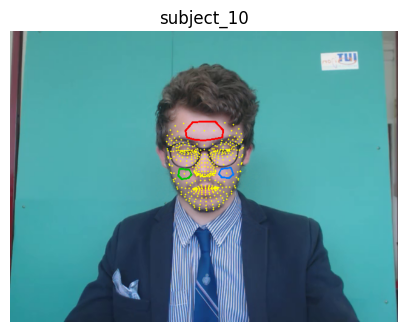

In [6]:
lmk = roi.make_landmarker()
COLORS = {"forehead": (255, 0, 0), "cheek_left": (0, 200, 0), "cheek_right": (0, 120, 255)}

def show_rois(frame, title=""):
    pts = roi.face_landmarks(lmk, frame)
    if pts is None:
        print("no face found"); return
    vis = frame.copy()
    for x, y in pts:
        cv2.circle(vis, (int(x), int(y)), 1, (255, 255, 0), -1)
    for name, idx in roi.ROI_LANDMARKS.items():
        cv2.polylines(vis, [cv2.convexHull(pts[idx])], True, COLORS[name], 2)
    for name, m in roi.roi_masks(pts, frame.shape).items():
        print(f"{name:12s} {m.sum():5d} px   mean RGB = {frame[m].mean(axis=0).round(1)}")
    plt.figure(figsize=(5, 5)); plt.imshow(vis); plt.title(title); plt.axis("off"); plt.show()

def grab_frame(video_path, n=0):
    """Frame number n of a video."""
    for i, f in enumerate(roi.iter_frames(video_path)):
        if i == n:
            return f

show_rois(first, sid)

In [7]:
t0 = time.time()
traces, fps = roi.extract_rgb(vid)
print(f"took {time.time() - t0:.0f} s  |  fps {fps:.2f}")
for name, tr in traces.items():
    print(f"{name:12s} shape {tr.shape}  frames with no face: {np.isnan(tr[:, 0]).sum()}"
          f"  mean RGB {np.nanmean(tr, axis=0).round(1)}")

took 51 s  |  fps 29.79
forehead     shape (2018, 3)  frames with no face: 0  mean RGB [208.2 174.4 184.3]
cheek_left   shape (2018, 3)  frames with no face: 0  mean RGB [182.3 149.3 153.8]
cheek_right  shape (2018, 3)  frames with no face: 0  mean RGB [188.4 154.  160.3]
all          shape (2018, 3)  frames with no face: 0  mean RGB [202.2 168.4 177.1]


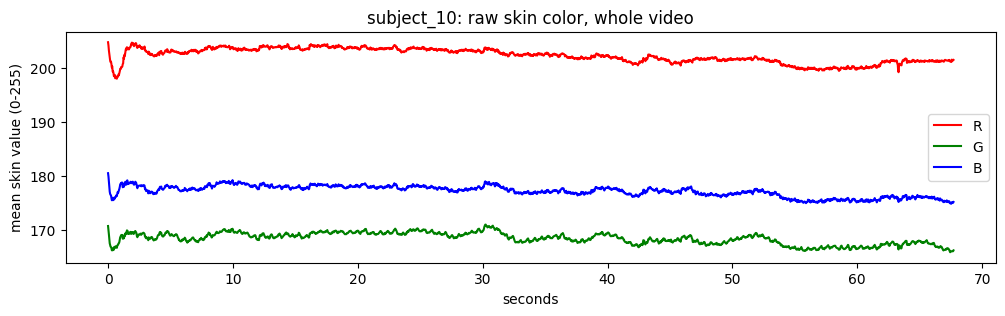

In [8]:
t_sec = np.arange(len(traces["all"])) / fps
plt.figure(figsize=(12, 3))
for c, color in enumerate(["red", "green", "blue"]):
    plt.plot(t_sec, traces["all"][:, c], color=color, label="RGB"[c])
plt.xlabel("seconds"); plt.ylabel("mean skin value (0-255)")
plt.title(f"{sid}: raw skin color, whole video"); plt.legend(); plt.show()

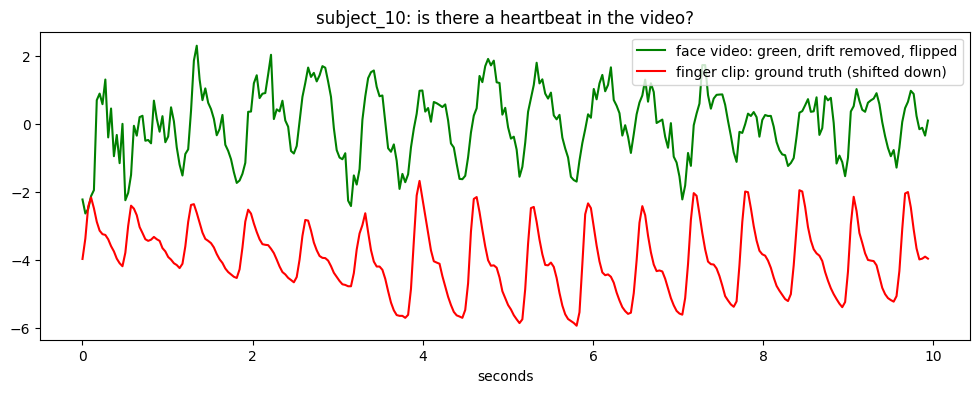

In [9]:
green = traces["all"][:, 1]
w = int(round(fps))
slow = np.convolve(green, np.ones(w) / w, mode="same")
pulse = -(green - slow)

n, s0 = int(10 * fps), w
tt = np.arange(n) / fps
plt.figure(figsize=(12, 4))
plt.plot(tt, z(pulse[s0:s0 + n]), color="green", label="face video: green, drift removed, flipped")
plt.plot(tt, z(ppg[s0:s0 + n]) - 4, color="red", label="finger clip: ground truth (shifted down)")
plt.xlabel("seconds"); plt.legend(loc="upper right")
plt.title(f"{sid}: is there a heartbeat in the video?"); plt.show()

forehead     kept  36%   mean RGB before [142. 111. 111.]  after [171. 138. 140.]
cheek_left   kept 100%   mean RGB before [208. 166. 171.]  after [208. 166. 171.]
cheek_right  kept 100%   mean RGB before [216. 174. 179.]  after [216. 174. 179.]


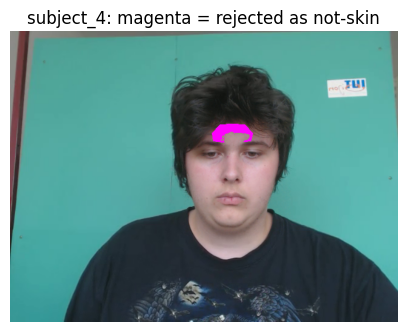

In [10]:
f4 = grab_frame(videos["subject_4"], 1200)
before = roi.roi_masks(roi.face_landmarks(lmk, f4), f4.shape)
after = roi.skin_masks(f4, before)
vis = f4.copy()
for name in before:
    vis[before[name] & ~after[name]] = (255, 0, 255)
    print(f"{name:12s} kept {after[name].sum() / before[name].sum():4.0%}   mean RGB "
          f"before {f4[before[name]].mean(0).round()}  after {f4[after[name]].mean(0).round()}")
plt.figure(figsize=(5, 5)); plt.imshow(vis); plt.axis("off")
plt.title("subject_4: magenta = rejected as not-skin"); plt.show()

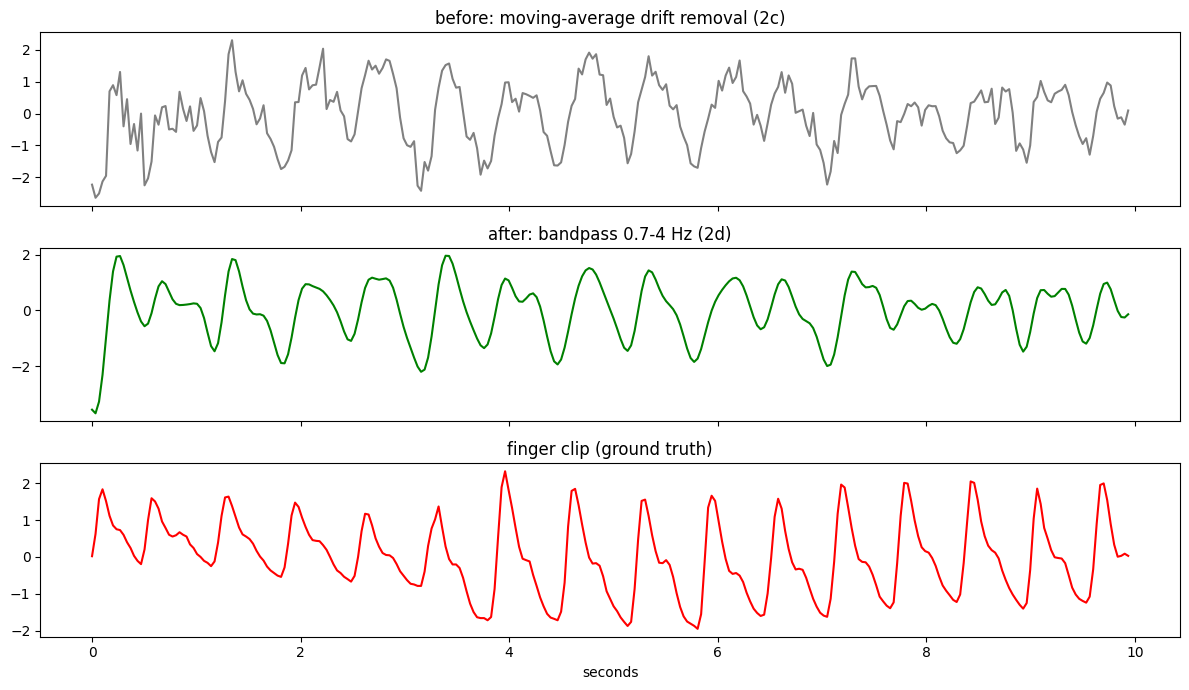

In [11]:
pulse_clean = sp.green_pulse(traces["all"], fps)

fig, ax = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
ax[0].plot(tt, z(pulse[s0:s0 + n]), color="gray");        ax[0].set_title("before: moving-average drift removal (2c)")
ax[1].plot(tt, z(pulse_clean[s0:s0 + n]), color="green"); ax[1].set_title("after: bandpass 0.7-4 Hz (2d)")
ax[2].plot(tt, z(ppg[s0:s0 + n]), color="red");           ax[2].set_title("finger clip (ground truth)")
ax[2].set_xlabel("seconds"); plt.tight_layout(); plt.show()

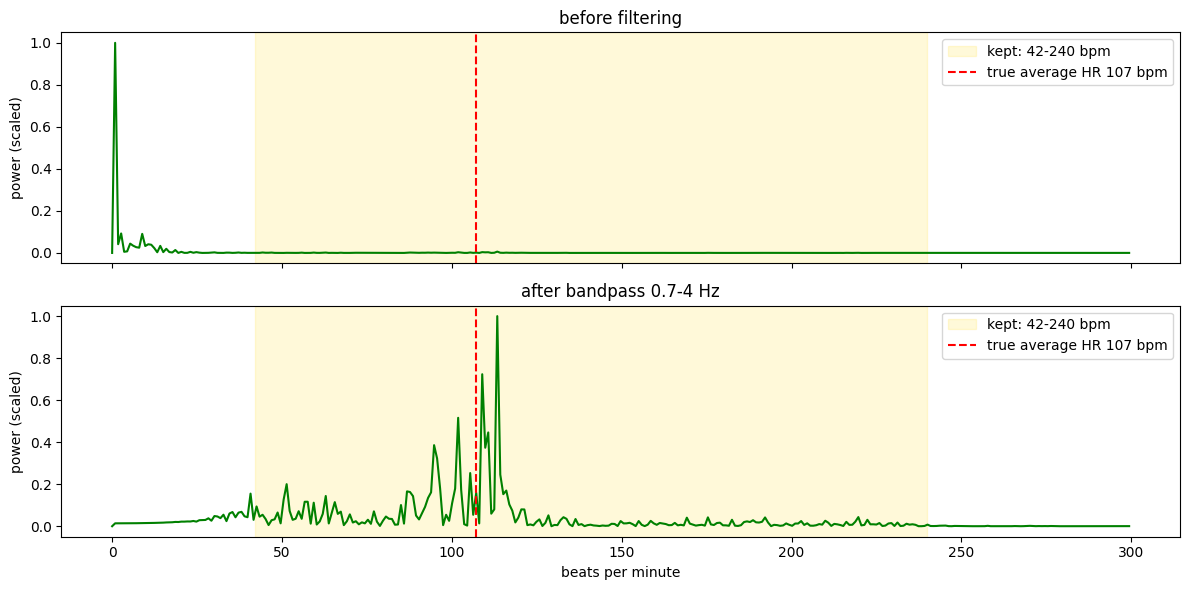

In [12]:
def spectrum(x, fps):
    x = x - x.mean()
    freqs = np.fft.rfftfreq(len(x), d=1 / fps)
    power = np.abs(np.fft.rfft(x)) ** 2
    return freqs * 60, power

raw = -sp.normalize(traces["all"])[:, 1]
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for a, sig, title in [(ax[0], raw, "before filtering"), (ax[1], pulse_clean, "after bandpass 0.7-4 Hz")]:
    bpm, power = spectrum(sig, fps)
    keep = bpm <= 300
    a.plot(bpm[keep], power[keep] / power[keep].max(), color="green")
    a.axvspan(42, 240, color="gold", alpha=0.15, label="kept: 42-240 bpm")
    a.axvline(hr.mean(), color="red", ls="--", label=f"true average HR {hr.mean():.0f} bpm")
    a.set_title(title); a.set_ylabel("power (scaled)"); a.legend(loc="upper right")
ax[1].set_xlabel("beats per minute")
plt.tight_layout(); plt.show()

56 windows | MAE 0.9 bpm | RMSE 1.8 bpm


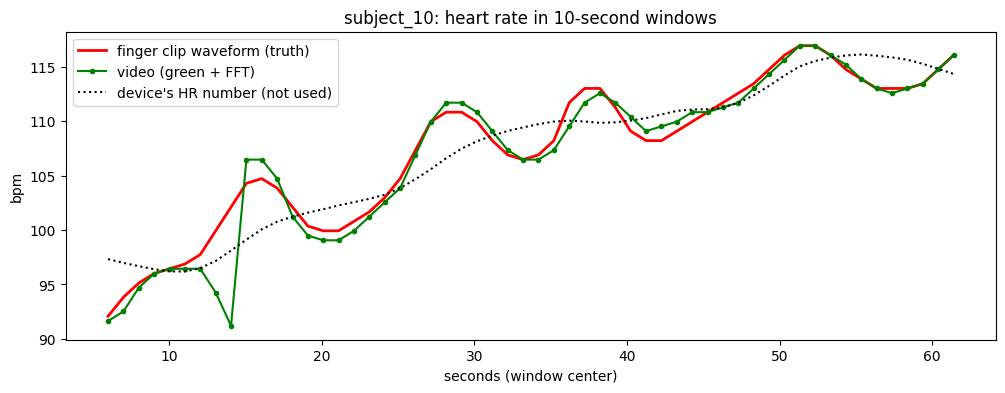

In [14]:
est  = sp.hr_per_window(pulse_clean, fps)
true = sp.true_hr_per_window(ppg, fps)
err = est["bpm"] - true["bpm"]
print(f"{len(err)} windows | MAE {np.mean(np.abs(err)):.1f} bpm | RMSE {np.sqrt(np.mean(err ** 2)):.1f} bpm")

win = int(round(10 * fps))
device = [hr[int(c * fps) - win // 2: int(c * fps) + win // 2].mean() for c in true["t"]]
plt.figure(figsize=(12, 4))
plt.plot(true["t"], true["bpm"], "r-", lw=2, label="finger clip waveform (truth)")
plt.plot(est["t"], est["bpm"], "g.-", label="video (green + FFT)")
plt.plot(true["t"], device, "k:", label="device's HR number (not used)")
plt.xlabel("seconds (window center)"); plt.ylabel("bpm"); plt.legend()
plt.title(f"{sid}: heart rate in 10-second windows"); plt.show()

In [16]:
chosen = ["subject_3", "subject_4", "subject_10", "subject_11",
          "subject_13", "subject_14", "subject_15", "subject_16"]
results = {}
maes = []
for s in chosen:
    if s not in videos:
        print(f"{s}: not found, skipping"); continue
    tr, f = roi.extract_rgb(videos[s])
    p, h, _ = data.load_ground_truth(gts[s])
    T = min(len(tr["all"]), len(p))
    est_s = sp.hr_per_window(sp.green_pulse(tr["all"][:T], f), f)["bpm"]
    true_s = sp.true_hr_per_window(p[:T], f)["bpm"]
    mae = np.mean(np.abs(est_s - true_s)); maes.append(mae)
    results[s] = {"traces": tr, "fps": f, "ppg": p[:T]}
    print(f"{s:11s} MAE {mae:5.1f} bpm | true HR {true_s.mean():5.1f} | "
          f"device's number says {h.mean():5.1f} (max {h.max():.0f})")
print(f"\nGREEN baseline over {len(maes)} subjects: "
      f"average MAE {np.mean(maes):.1f} bpm, median {np.median(maes):.1f} bpm")

subject_3   MAE   2.4 bpm | true HR 105.6 | device's number says 112.3 (max 116)
subject_4   MAE   0.5 bpm | true HR  98.5 | device's number says  98.3 (max 102)
subject_10  MAE   0.9 bpm | true HR 107.4 | device's number says 107.1 (max 119)
subject_11  MAE   5.6 bpm | true HR  74.2 | device's number says  80.4 (max 98)
subject_13  MAE   0.5 bpm | true HR  93.0 | device's number says  91.8 (max 98)
subject_14  MAE   0.3 bpm | true HR  86.7 | device's number says  85.4 (max 91)
subject_15  MAE   4.1 bpm | true HR 120.9 | device's number says 103.8 (max 127)
subject_16  MAE   4.6 bpm | true HR 126.6 | device's number says  60.2 (max 127)

GREEN baseline over 8 subjects: average MAE 2.3 bpm, median 1.6 bpm


subject_10: green MAE 0.9 bpm | POS MAE 0.4 bpm


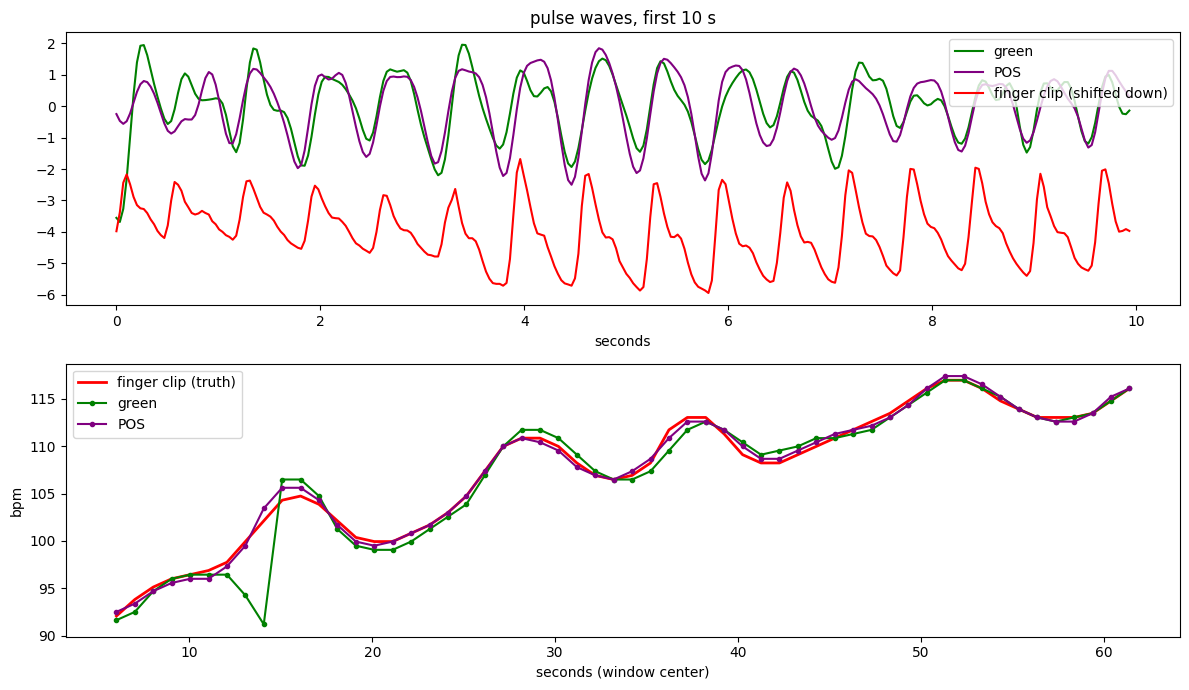

In [15]:
pulse_pos = sp.pos_pulse(traces["all"], fps)
est_pos = sp.hr_per_window(pulse_pos, fps)
print(f"{sid}: green MAE {np.mean(np.abs(est['bpm'] - true['bpm'])):.1f} bpm | "
      f"POS MAE {np.mean(np.abs(est_pos['bpm'] - true['bpm'])):.1f} bpm")

fig, ax = plt.subplots(2, 1, figsize=(12, 7))
ax[0].plot(tt, z(pulse_clean[s0:s0 + n]), color="green", label="green")
ax[0].plot(tt, z(pulse_pos[s0:s0 + n]), color="purple", label="POS")
ax[0].plot(tt, z(ppg[s0:s0 + n]) - 4, color="red", label="finger clip (shifted down)")
ax[0].set_xlabel("seconds"); ax[0].legend(loc="upper right"); ax[0].set_title("pulse waves, first 10 s")
ax[1].plot(true["t"], true["bpm"], "r-", lw=2, label="finger clip (truth)")
ax[1].plot(est["t"], est["bpm"], "g.-", label="green")
ax[1].plot(est_pos["t"], est_pos["bpm"], ".-", color="purple", label="POS")
ax[1].set_xlabel("seconds (window center)"); ax[1].set_ylabel("bpm"); ax[1].legend()
plt.tight_layout(); plt.show()

In [16]:
seconds = np.arange(len(traces["all"])) / fps
flicker = 1 + 0.002 * np.sin(2 * np.pi * 1.0 * seconds)[:, None]   # +-0.2%, once per second = 60 bpm
fake = traces["all"] * flicker                                      # [:, None] applies it to R, G and B equally
for name, method in [("green", sp.green_pulse), ("POS", sp.pos_pulse)]:
    bpm = sp.hr_per_window(method(fake, fps), fps)["bpm"]
    print(f"{name:5s} with flicker: median estimate {np.median(bpm):5.1f} bpm | "
          f"MAE {np.mean(np.abs(bpm - true['bpm'])):5.1f}   (truth median {np.median(true['bpm']):.1f})")

green with flicker: median estimate  60.2 bpm | MAE  47.4   (truth median 108.7)
POS   with flicker: median estimate 109.1 bpm | MAE   0.4   (truth median 108.7)
